# Практическое занятие 2. Линейная и полиномиальная регрессия для оценки КПД Версия преподавателя

## Назначение занятия

Цель занятия - построить регрессионную модель для оценки коэффициента
полезного действия электромеханического преобразователя.

Регрессия (regression) - задача машинного обучения, в которой требуется
предсказать непрерывную числовую величину. В данном занятии целевая переменная
- `efficiency`, то есть КПД в долях единицы.


## Теоретические сведения

Линейная регрессия (linear regression) строит зависимость вида
$\hat{y} = b_0 + b_1 x_1 + ... + b_p x_p$, где $\hat{y}$ - прогноз модели,
$x_1...x_p$ - признаки, а $b_0...b_p$ - настраиваемые параметры.

Полиномиальная регрессия (polynomial regression) добавляет к исходным
признакам степени и произведения признаков. Это позволяет описывать нелинейные
зависимости, но увеличивает риск переобучения.

Регуляризация (regularization) - ограничение сложности модели. В гребневой
регрессии (Ridge regression) используется L2-регуляризация, то есть штраф за
большие значения коэффициентов модели:

$J(b) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} b_j^2$.

Параметр $\alpha$ задает силу штрафа: чем он больше, тем сильнее модель
ограничивает абсолютные значения коэффициентов.

В этом занятии регрессионная модель сравнивается с базовой моделью
(baseline model). Базовая модель не использует признаки и всегда прогнозирует
среднее значение КПД по обучающей выборке. Если более сложная модель не
превосходит такой ориентир, ее применение методически не обосновано.


## Как работает линейная регрессионная модель

Линейная регрессия (linear regression) рассматривает прогноз как взвешенную
сумму признаков. В матричной форме модель записывается так:

$$\hat{y} = Xb,$$

где `X` - матрица признаков, `b` - вектор коэффициентов, `y` - вектор
фактических значений целевой переменной, `y_hat` - вектор прогнозов. Если
используется свободный член, к матрице `X` добавляется столбец единиц.

Обучение модели означает подбор таких коэффициентов, при которых прогнозы
минимально отличаются от фактических значений на обучающей выборке. В обычной
линейной регрессии минимизируется сумма квадратов ошибок:

$$L(b) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2.$$

Ошибка `e_i = y_i - y_hat_i` называется остатком (residual). Остаток
показывает, какая часть фактического значения не объяснена моделью. После
обучения важно анализировать не только среднюю ошибку, но и структуру
остатков. Если остатки систематически зависят от скорости, тока или
температуры, модель не описывает часть физической зависимости.

Коэффициент линейной модели показывает направление связи между признаком и
прогнозом при прочих равных условиях. Однако такая интерпретация корректна
только с учетом масштаба признаков и корреляций между ними. Поэтому в
блокноте используется стандартизация: из каждого признака вычитается среднее
значение и результат делится на стандартное отклонение. Стандартизованный
признак имеет среднее значение около 0 и стандартное отклонение около 1.


## Как работает полиномиальная гребневая регрессия

Полиномиальные признаки позволяют линейной модели описывать нелинейные
зависимости. Например, если исходными признаками являются `x1` и `x2`, то при
степени 2 к ним могут быть добавлены `x1^2`, `x1*x2` и `x2^2`. После такого
преобразования модель остается линейной по коэффициентам, но становится
нелинейной по исходным физическим признакам:

$$\hat{y} = b_0 + b_1x_1 + b_2x_2 + b_3x_1^2 + b_4x_1x_2 + b_5x_2^2.$$

Увеличение числа признаков повышает гибкость модели, но одновременно
увеличивает риск переобучения. Переобучение (overfitting) - ситуация, когда
модель слишком точно описывает обучающую выборку и хуже переносится на новые
данные.

Гребневая регрессия (Ridge regression) уменьшает этот риск с помощью
L2-регуляризации. Регуляризация добавляет штраф за большие коэффициенты:

$$J(b) = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 +
\alpha \sum_{j=1}^{p} b_j^2.$$

Параметр `alpha` управляет силой штрафа. При малом `alpha` модель ближе к
обычной линейной регрессии. При большом `alpha` коэффициенты сильнее
сжимаются к нулю, модель становится устойчивее, но может потерять важные
зависимости. В инженерной интерпретации это означает компромисс между
гибкостью модели и устойчивостью прогноза.


## Источники и проверка актуальности

1. ElectricMotorTemperature, Zenodo TSML Archive - открытый набор многомерных временных рядов для регрессии температуры электродвигателя. Используется как реальный ориентир структуры временных признаков. URL: https://zenodo.org/records/11235562
2. IEC 60034-1:2026. Rotating electrical machines - Part 1: Rating and performance. Используется как нормативный ориентир терминологии вращающихся электрических машин. URL: https://webstore.iec.ch/en/publication/89961
3. IEC 60034-2-1:2024. Rotating electrical machines - Part 2-1: Standard methods for determining losses and efficiency from tests. Используется как нормативный ориентир по потерям и КПД. URL: https://webstore.iec.ch/en/publication/67756
4. Документация pandas по пропущенным данным. URL: https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html
5. Документация scikit-learn по моделям, разбиению данных и метрикам качества. URL: https://scikit-learn.org/stable/

Дата проверки актуальности ссылок: 2026-05-07.


## Рекомендуемые реальные наборы данных для занятий 1-2

Базовый учебный CSV в этом блокноте сохраняется для гарантированного запуска
в аудитории. При расширении работы его целесообразно сопоставлять с реальными
открытыми наборами данных:

1. ElectricMotorTemperature, Zenodo TSML Archive. URL:
   https://zenodo.org/records/11235562. Набор содержит открытые
   многомерные временные ряды (multivariate time series, многоканальные
   временные последовательности) для регрессии температуры электродвигателя.
   Применение: первичный анализ данных, регрессия температуры, обсуждение
   временной автокорреляции и группового разбиения. Ограничение: исходный
   формат `.ts` не содержит физических имен каналов, поэтому признаки в
   учебной таблице обозначаются нейтрально: `channel_00_mean`,
   `channel_01_mean` и далее.
2. Zenodo PMSM inverter fault diagnosis. URL:
   https://zenodo.org/records/14482932. Компактный набор измерений
   PMSM-инвертора с режимами отказов, фазными токами, напряжением
   звена постоянного тока и температурными признаками. Применение:
   первичный анализ, классификация и упрощенная регрессия температур.
   Ограничение: исходная постановка ближе к диагностике, чем к расчету КПД.
3. Processed Data for EV Powertrain Efficiency, Mendeley Data. URL:
   https://data.mendeley.com/datasets/kbwr2z8r3y. Набор
   предназначен для анализа эффективности электропривода транспортного
   средства. Применение: дополнительный пример перехода от траекторных
   данных к расчетной карте КПД. Ограничение: КПД является расчетным, а не
   стендовым измерением двигателя.

Методическое решение для эталонного занятия: использовать малый учебный CSV
как обязательный набор, а реальные источники - как расширение для проектов,
докладов и самостоятельной доработки.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


# Поиск корня учебного проекта.
# Если блокнот запускается из корня репозитория, Path.cwd() уже указывает
# на нужный каталог. Если блокнот открыт из папки notebooks/student или
# notebooks/teacher, проверяются родительские каталоги.
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "src").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Не найден корень проекта. Запустите блокнот из каталога appai_lab "
        "или укажите путь к проекту вручную."
    )

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


DATA_DIR = PROJECT_ROOT / "data" / "processed"
DATA_FILE = DATA_DIR / "practice_02_motor_efficiency_features.csv"
DIAGNOSTICS_FILE = DATA_DIR / "practice_02_motor_efficiency_diagnostics.csv"
CATALOG_FILE = DATA_DIR / "practice_01_03_dataset_catalog.csv"
ASSIGNMENTS_FILE = DATA_DIR / "practice_01_03_dataset_assignments.csv"

if not DATA_FILE.exists() or not CATALOG_FILE.exists() or not ASSIGNMENTS_FILE.exists() or (DIAGNOSTICS_FILE is not None and not DIAGNOSTICS_FILE.exists()):
    raise FileNotFoundError(
        "Не найдены учебные CSV-файлы. Выполните из корня проекта команду "
        "`python scripts/generate_datasets.py`, затем повторно запустите блокнот."
    )

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

RANDOM_STATE = 20260507


def draw_process_diagram(labels, title):
    """Построить простую схему последовательности этапов работы.

    Схема используется как учебная визуализация. Она не является алгоритмом,
    а показывает логическую структуру анализа: от источника данных к выводу.
    """
    fig, ax = plt.subplots(figsize=(max(10, 2.2 * len(labels)), 2.3))
    ax.set_axis_off()
    x_positions = np.linspace(0.06, 0.94, len(labels))

    for index, (x_pos, label) in enumerate(zip(x_positions, labels)):
        box = FancyBboxPatch(
            (x_pos - 0.075, 0.40),
            0.15,
            0.28,
            boxstyle="round,pad=0.02",
            linewidth=1.2,
            edgecolor="black",
            facecolor="#e8f1f8",
            transform=ax.transAxes,
        )
        ax.add_patch(box)
        ax.text(
            x_pos,
            0.54,
            label,
            ha="center",
            va="center",
            fontsize=10,
            wrap=True,
            transform=ax.transAxes,
        )
        if index < len(labels) - 1:
            arrow = FancyArrowPatch(
                (x_pos + 0.085, 0.54),
                (x_positions[index + 1] - 0.085, 0.54),
                arrowstyle="->",
                mutation_scale=12,
                linewidth=1.1,
                color="black",
                transform=ax.transAxes,
            )
            ax.add_patch(arrow)

    ax.set_title(title, fontsize=13, pad=14)
    plt.show()


def plot_correlation_heatmap(data, columns, title):
    """Построить тепловую карту корреляций без дополнительных библиотек."""
    corr = data[columns].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Коэффициент корреляции")

    for i in range(len(columns)):
        for j in range(len(columns)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

DATA_FILE


PosixPath('/mnt/f/projects/appai_lab/data/processed/practice_02_motor_efficiency_features.csv')

## Логическая схема регрессионного моделирования

Регрессионная модель должна проверяться на данных, которые не использовались
при обучении. Поэтому процедура включает явное разделение на обучающую и
тестовую выборки. Масштабирование признаков выполняется только внутри
вычислительного конвейера (pipeline), чтобы одна и та же процедура применялась
к обучающим и тестовым данным.


## Последовательность подготовки данных и использования регрессионной модели

Регрессионный эксперимент должен выполняться в фиксированной
последовательности. Нарушение порядка может привести к утечке данных и
завышенной оценке качества.

1. Сформулировать задачу: указать, какая непрерывная величина прогнозируется,
   в каких единицах она измеряется и зачем такой прогноз нужен инженерно.
2. Выбрать целевую переменную (target variable): в данном занятии это
   `efficiency`, то есть коэффициент полезного действия.
3. Определить момент прогноза: какие признаки доступны до расчета КПД, а
   какие появляются только после расчета мощности и потерь.
4. Исключить признаки с утечкой данных (data leakage): целевую переменную,
   производные от нее величины и служебные поля, которые прямо раскрывают
   ответ.
5. Проверить распределение целевой переменной и признаков: слишком узкий
   диапазон цели ограничивает применимость модели.
6. Разделить данные на обучающую и тестовую выборки (train/test split).
   Обучающая выборка используется для подбора параметров, тестовая - только
   для независимой проверки.
7. Построить базовую модель (baseline model). В регрессии таким ориентиром
   может быть прогноз средним значением целевой переменной.
8. Создать вычислительный конвейер (pipeline), в котором предобработка и
   модель объединены в одну процедуру. Это предотвращает ситуацию, когда
   параметры масштабирования вычислены по всей таблице до разбиения.
9. Обучить модель только на обучающей выборке.
10. Получить прогнозы на тестовой выборке и рассчитать MAE, RMSE и R2.
11. Построить график фактических и прогнозных значений, а также график
    остатков. Эти графики помогают увидеть систематические ошибки.
12. Сравнить модель с базовым ориентиром и сформулировать инженерное
    ограничение применения модели.

После обучения модель используется следующим образом: новое наблюдение
проходит те же операции предобработки, затем модель вычисляет прогноз
`y_hat`. Если новое наблюдение выходит за диапазоны обучающих данных, прогноз
следует считать экстраполяцией, то есть применением модели вне области, где
она была проверена. Экстраполяция требует отдельной инженерной осторожности.


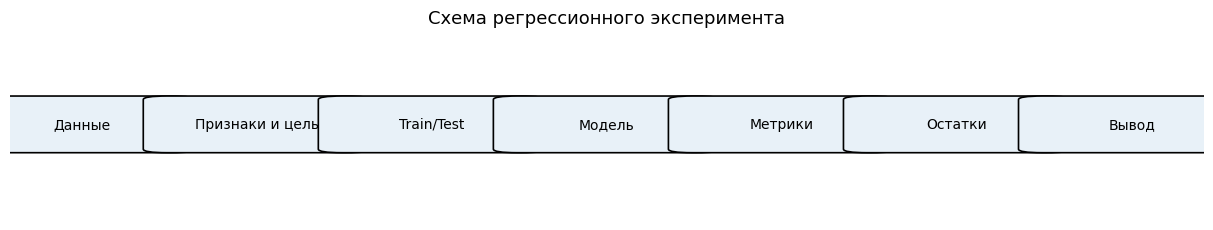

In [2]:
draw_process_diagram(
    [
        "Данные",
        "Признаки и цель",
        "Train/Test",
        "Модель",
        "Метрики",
        "Остатки",
        "Вывод",
    ],
    "Схема регрессионного эксперимента",
)


In [3]:
df = pd.read_csv(DATA_FILE)
diagnostics_df = pd.read_csv(DIAGNOSTICS_FILE)
full_df = df.merge(diagnostics_df, on="sample_id", how="left", validate="one_to_one")

print(f"Размер таблицы: {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()


Размер таблицы: 300 строк, 8 столбцов


,sample_id,profile_id,speed_rpm,torque_nm,voltage_v,temperature_c,ambient_temp_c,efficiency
0,1,2,18418.8,0.04171,24.016,36.135,24.503,0.69034
1,2,3,25827.8,0.08093,47.557,43.198,24.053,0.78778
2,3,6,61621.7,0.01927,36.162,62.001,29.330,0.59082
3,4,2,13520.9,0.05527,60.091,41.650,31.030,0.84407
4,5,2,18556.2,0.08375,59.419,46.810,27.667,0.74382


## Структура регрессионного набора данных

В занятии 2 используется таблица без искусственно добавленных пропусков.
Каждая строка соответствует одному режиму электромеханического
преобразователя. Целевая переменная `efficiency` является непрерывной
величиной, поэтому задача относится к регрессии. Перед обучением модели
необходимо проверить распределение целевой переменной и связь цели с
основными физическими признаками.


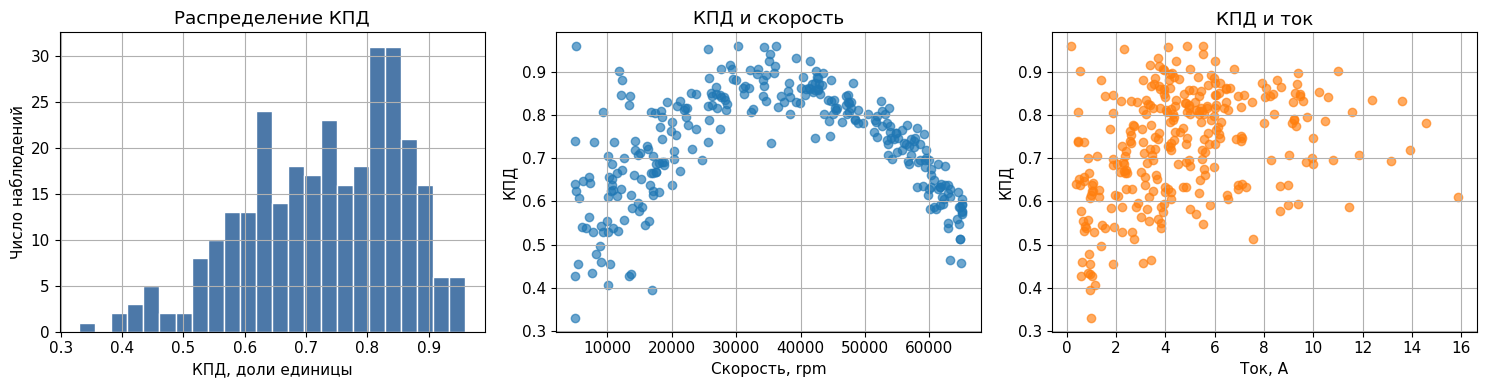

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["efficiency"], bins=24, color="#4c78a8", edgecolor="white")
axes[0].set_title("Распределение КПД")
axes[0].set_xlabel("КПД, доли единицы")
axes[0].set_ylabel("Число наблюдений")

axes[1].scatter(df["speed_rpm"], df["efficiency"], alpha=0.65)
axes[1].set_title("КПД и скорость")
axes[1].set_xlabel("Скорость, rpm")
axes[1].set_ylabel("КПД")

axes[2].scatter(full_df["current_a"], full_df["efficiency"], alpha=0.65, color="tab:orange")
axes[2].set_title("КПД и ток")
axes[2].set_xlabel("Ток, A")
axes[2].set_ylabel("КПД")

plt.tight_layout()
plt.show()


## Выбор признаков

В признаки включаются только величины, которые доступны до расчета КПД:
`speed_rpm`, `torque_nm`, `voltage_v`, `temperature_c`,
`ambient_temp_c`. Столбцы `current_a`, `output_power_w`, `loss_power_w`,
`torque_limit_nm` и сама целевая переменная `efficiency` не используются в
строгой базовой постановке как входные признаки, поскольку ток совместно со
скоростью, моментом и напряжением позволяет косвенно восстановить КПД через
энергетическое тождество, а мощность и потери раскрывают цель напрямую.

Утечка данных (data leakage) - ситуация, когда в признаки попадает информация,
которая в реальной задаче недоступна на момент прогноза или прямо связана с
целевой переменной.


## Критерии допустимости признаков

Критерии допустимости признаков (feature eligibility criteria) определяют,
можно ли использовать столбец как вход модели. Признак допустим, если он
доступен в момент предполагаемого прогноза, имеет понятный физический смысл и
не является прямым преобразованием целевой переменной.

Следует различать три группы столбцов:

1. измеряемые признаки (measured features): ток, напряжение, скорость, момент,
   температура;
2. расчетные признаки (derived features): мощность, потери, КПД, запасы до
   ограничений;
3. служебные признаки (technical identifiers): идентификаторы строк и профилей.

Измеряемые признаки обычно допустимы при физическом обосновании. Расчетные
признаки требуют проверки на утечку данных. Служебные признаки не должны
использоваться как физические входы модели.


In [5]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


feature_columns = ['speed_rpm', 'torque_nm', 'voltage_v', 'temperature_c', 'ambient_temp_c']
target_column = "efficiency"

X = df[feature_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)


Обучающая выборка: (225, 5)
Тестовая выборка: (75, 5)


## Диагностика разбиения на обучающую и тестовую выборки

После разбиения необходимо проверить, что обучающая и тестовая выборки
сопоставимы по распределению целевой переменной. Если тестовая выборка
содержит только узкий диапазон КПД, итоговые метрики будут плохо отражать
качество модели на всем диапазоне режимов.

Для реальных временных рядов случайное разбиение может быть недостаточным:
соседние точки одного профиля измерения похожи друг на друга, поэтому модель
может получить завышенную оценку качества. В таких случаях применяют разбиение
по времени или по группам профилей.


In [6]:
split_diagnostics = pd.DataFrame(
    {
        "train": y_train.describe(),
        "test": y_test.describe(),
    }
)
split_diagnostics


,train,test
count,225.000000,75.000000
mean,0.733721,0.721783
std,0.130444,0.113110
min,0.329820,0.435310
25%,0.633200,0.649870
50%,0.756430,0.721680
75%,0.833660,0.816955
max,0.960000,0.924170


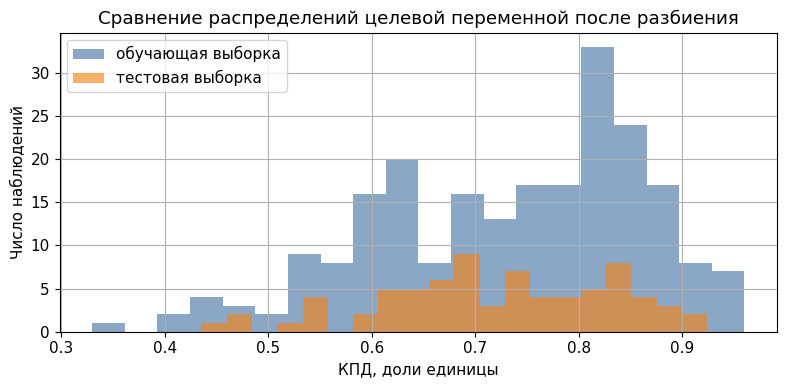

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_train, bins=20, alpha=0.65, label="обучающая выборка", color="#4c78a8")
ax.hist(y_test, bins=20, alpha=0.65, label="тестовая выборка", color="#f58518")
ax.set_xlabel("КПД, доли единицы")
ax.set_ylabel("Число наблюдений")
ax.set_title("Сравнение распределений целевой переменной после разбиения")
ax.legend()
plt.tight_layout()
plt.show()


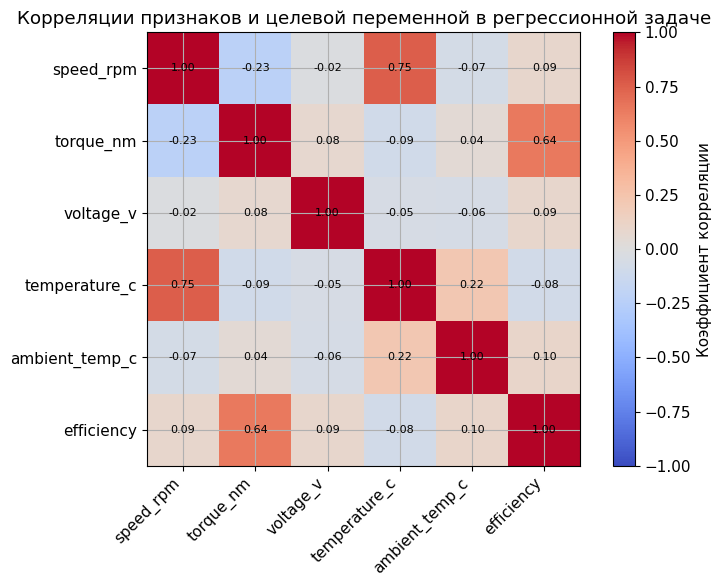

In [8]:
plot_correlation_heatmap(
    df,
    feature_columns + [target_column],
    "Корреляции признаков и целевой переменной в регрессионной задаче",
)


## Обучение моделей

Обучающая выборка используется для настройки параметров модели. Тестовая
выборка используется только для итоговой проверки качества на данных, которые
модель не видела при обучении.


## Вычислительный конвейер модели

Вычислительный конвейер модели (model pipeline) объединяет предварительную
обработку признаков и саму модель в одну процедуру. Это важно, потому что все
параметры предварительной обработки должны оцениваться только на обучающей
выборке. В данном занятии стандартизация (standardization), построение
полиномиальных признаков (polynomial features) и регрессия выполняются как
последовательные этапы одного конвейера.

Такой подход уменьшает риск методической ошибки: модель обучается и
применяется к новым данным с одной и той же последовательностью преобразований.


In [9]:
linear_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)

polynomial_ridge_model = Pipeline(
    steps=[
        ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]
)

models = {
    "linear_regression": linear_model,
    "polynomial_ridge": polynomial_ridge_model,
}

for model in models.values():
    model.fit(X_train, y_train)


## Интерпретация коэффициентов линейной модели

После стандартизации признаков коэффициенты линейной модели можно использовать
как приблизительный ориентир направления влияния признаков. Положительный
коэффициент означает, что при прочих равных условиях рост стандартизованного
признака связан с ростом прогноза КПД. Отрицательный коэффициент связан со
снижением прогноза. Такой вывод является статистическим и не заменяет
физическое обоснование.


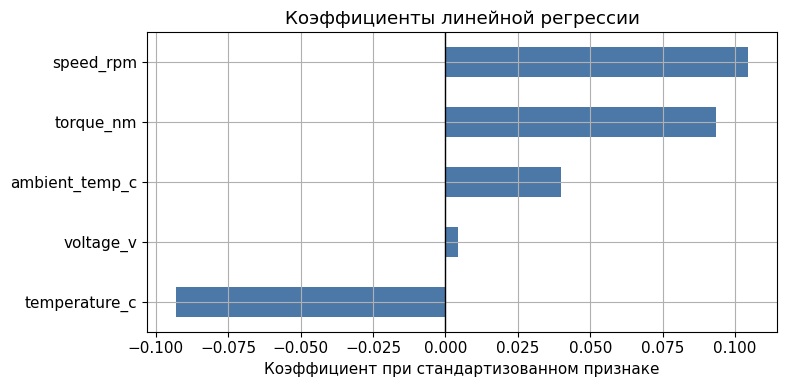

,coefficient
temperature_c,-0.093150
voltage_v,0.004414
ambient_temp_c,0.039976
torque_nm,0.093280
speed_rpm,0.104598


In [10]:
linear_coefficients = pd.Series(
    linear_model.named_steps["model"].coef_,
    index=feature_columns,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
linear_coefficients.plot(kind="barh", ax=ax, color="#4c78a8")
ax.axvline(0.0, color="black", linewidth=1)
ax.set_xlabel("Коэффициент при стандартизованном признаке")
ax.set_title("Коэффициенты линейной регрессии")
plt.tight_layout()
plt.show()

linear_coefficients.to_frame("coefficient")


## Метрики качества

Средняя абсолютная ошибка (Mean Absolute Error, MAE) показывает средний модуль
ошибки. Корень из средней квадратичной ошибки (Root Mean Squared Error, RMSE)
сильнее штрафует крупные ошибки. Коэффициент детерминации (coefficient of
determination, R2) показывает, какая доля изменчивости целевой переменной
объясняется моделью относительно прогноза средним значением.

$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$.

$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$.

$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$.

MAE и RMSE выражаются в единицах целевой переменной. В данной работе это доли
единицы КПД; после умножения на 100 они интерпретируются как процентные
пункты КПД. Коэффициент детерминации $R^2$ является безразмерной метрикой и
на тестовой выборке может быть отрицательным, если модель хуже прогноза
средним значением.


## Правило интерпретации качества модели

Качество регрессионной модели оценивается не по одной метрике, а по
совокупности признаков: улучшение относительно базовой модели, величина
ошибки в физических единицах, отсутствие выраженной структуры остатков и
устойчивость результата при изменении сложности модели. Высокое значение R2
не является самостоятельным доказательством физической корректности модели.

Модель допустима для предварительной инженерной оценки только в пределах
области данных, на которой она проверялась. Применение за пределами диапазона
скоростей, моментов, токов и температур является экстраполяцией
(extrapolation) и требует отдельного обоснования.


In [11]:
def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }


metrics = []
predictions = {}

baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean(), dtype=float)
predictions["mean_baseline"] = baseline_pred
baseline_row = {"model": "mean_baseline"}
baseline_row.update(regression_metrics(y_test, baseline_pred))
metrics.append(baseline_row)

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    row = {"model": name}
    row.update(regression_metrics(y_test, y_pred))
    metrics.append(row)

metrics_df = pd.DataFrame(metrics).set_index("model")
metrics_df


,MAE,RMSE,R2
model,,,
mean_baseline,0.092886,0.112986,-0.011290
linear_regression,0.052820,0.072564,0.582876
polynomial_ridge,0.041307,0.056623,0.746012


## Улучшение относительно базовой модели

MAE и RMSE выражены в долях единицы КПД. Умножение ошибки на 100 переводит ее
в процентные пункты КПД. Например, MAE = 0.02 означает среднюю абсолютную
ошибку около двух процентных пунктов.


In [12]:
metrics_interpretation = metrics_df.copy()
metrics_interpretation["MAE_percent_points"] = metrics_interpretation["MAE"] * 100.0
metrics_interpretation["RMSE_percent_points"] = metrics_interpretation["RMSE"] * 100.0
metrics_interpretation["MAE_improvement_vs_baseline"] = (
    metrics_interpretation.loc["mean_baseline", "MAE"] - metrics_interpretation["MAE"]
) * 100.0
metrics_interpretation["RMSE_improvement_vs_baseline"] = (
    metrics_interpretation.loc["mean_baseline", "RMSE"] - metrics_interpretation["RMSE"]
) * 100.0

metrics_interpretation


,MAE,RMSE,R2,MAE_percent_points,RMSE_percent_points,MAE_improvement_vs_baseline,RMSE_improvement_vs_baseline
model,,,,,,,
mean_baseline,0.092886,0.112986,-0.011290,9.288618,11.298619,0.000000,0.000000
linear_regression,0.052820,0.072564,0.582876,5.281969,7.256378,4.006649,4.042241
polynomial_ridge,0.041307,0.056623,0.746012,4.130696,5.662317,5.157922,5.636302


## Демонстрация косвенной и прямой утечки данных

Косвенная утечка данных возникает, когда целевая переменная не включена в
признаки напрямую, но может быть восстановлена из их нелинейной комбинации.
Для КПД действует энергетическое соотношение
`efficiency = output_power_w / (voltage_v * current_a)`, а
`output_power_w = torque_nm * omega`. Поэтому одновременное использование
`speed_rpm`, `torque_nm`, `voltage_v` и `current_a` позволяет полиномиальной
модели приблизиться к расчетной формуле КПД.

Прямая утечка данных возникает при включении `output_power_w` или
`loss_power_w`: эти величины являются расчетными компонентами целевой
переменной. Ниже такой вариант оставлен только как контролируемая
демонстрация методической ошибки.


In [13]:
leakage_demo_columns = [
    "speed_rpm",
    "torque_nm",
    "voltage_v",
    "temperature_c",
    "ambient_temp_c",
    "current_a",
    "output_power_w",
    "loss_power_w",
]

leakage_X = full_df[leakage_demo_columns]
leakage_X_train = leakage_X.loc[X_train.index]
leakage_X_test = leakage_X.loc[X_test.index]

leakage_demo_model = Pipeline(
    steps=[
        ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]
)
leakage_demo_model.fit(leakage_X_train, y_train)
leakage_demo_pred = leakage_demo_model.predict(leakage_X_test)

leakage_metrics = pd.DataFrame(
    [
        {"model": "strict_polynomial_ridge", **regression_metrics(y_test, predictions["polynomial_ridge"])},
        {"model": "leakage_demo_polynomial_ridge", **regression_metrics(y_test, leakage_demo_pred)},
    ]
).set_index("model")

leakage_metrics


,MAE,RMSE,R2
model,,,
strict_polynomial_ridge,0.041307,0.056623,0.746012
leakage_demo_polynomial_ridge,0.019254,0.028263,0.936722


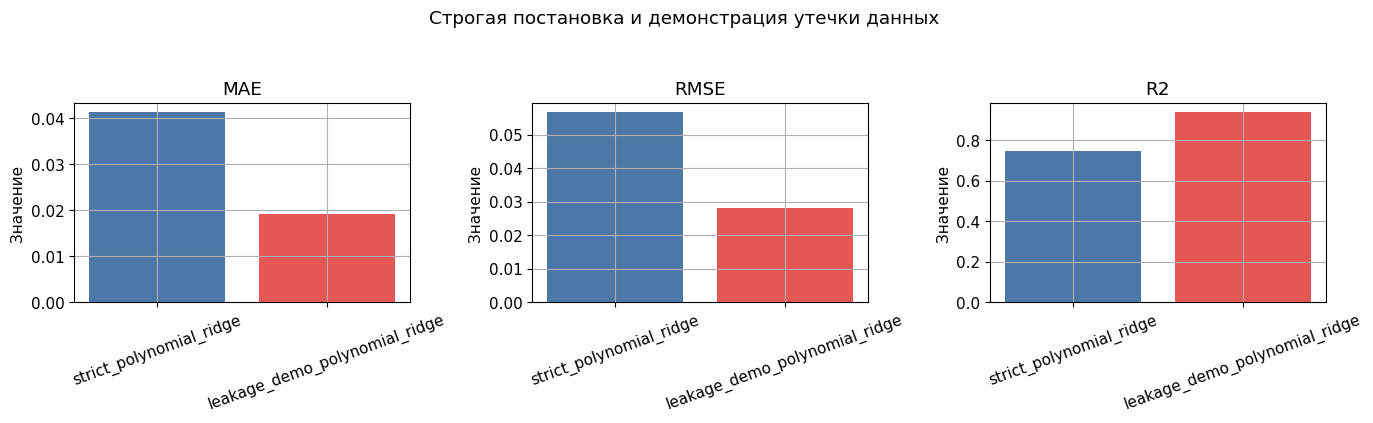

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    ax.bar(leakage_metrics.index, leakage_metrics[metric], color=["#4c78a8", "#e45756"])
    ax.set_title(metric)
    ax.set_ylabel("Значение")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Строгая постановка и демонстрация утечки данных", y=1.05)
plt.tight_layout()
plt.show()


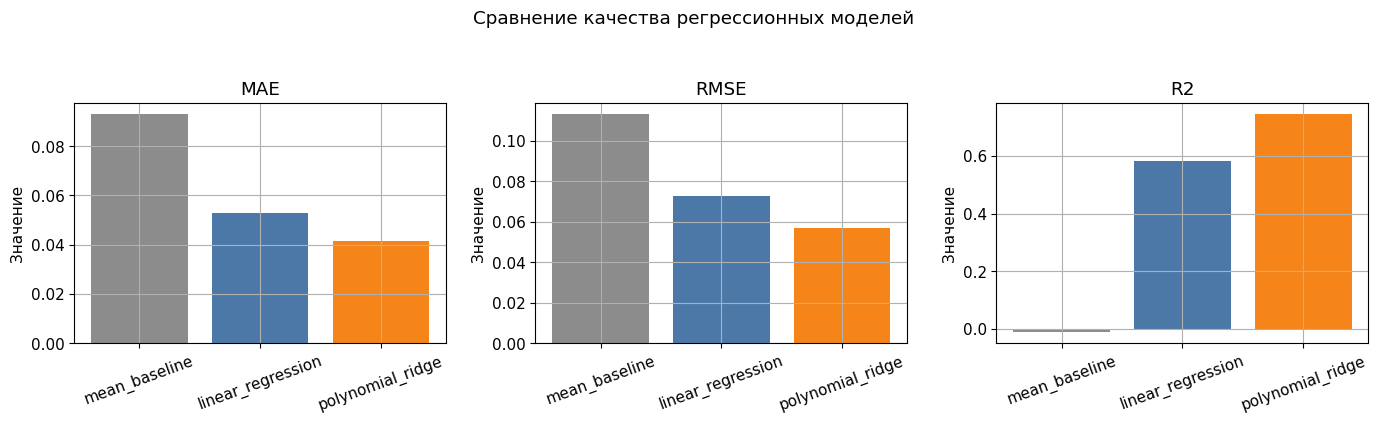

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    axes_data = metrics_df[metric]
    colors = ["#8c8c8c", "#4c78a8", "#f58518"][: len(axes_data)]
    ax.bar(axes_data.index, axes_data.values, color=colors)
    ax.set_title(metric)
    ax.set_ylabel("Значение")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Сравнение качества регрессионных моделей", y=1.05)
plt.tight_layout()
plt.show()


## Графики прогноза и остатков

Остаток - разность между фактическим значением и прогнозом модели. Если
остатки имеют выраженную структуру, модель не описывает часть зависимости.


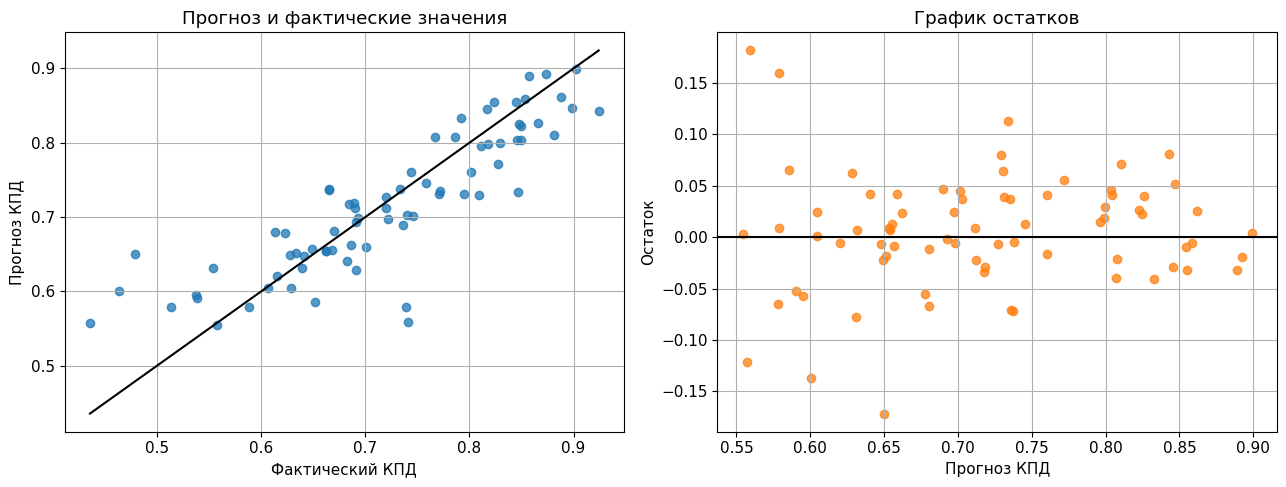

In [16]:
selected_model_name = "polynomial_ridge"
selected_pred = predictions[selected_model_name]
residuals = y_test - selected_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, selected_pred, alpha=0.75)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="black")
axes[0].set_xlabel("Фактический КПД")
axes[0].set_ylabel("Прогноз КПД")
axes[0].set_title("Прогноз и фактические значения")

axes[1].scatter(selected_pred, residuals, alpha=0.75, color="tab:orange")
axes[1].axhline(0.0, color="black")
axes[1].set_xlabel("Прогноз КПД")
axes[1].set_ylabel("Остаток")
axes[1].set_title("График остатков")

plt.tight_layout()
plt.show()


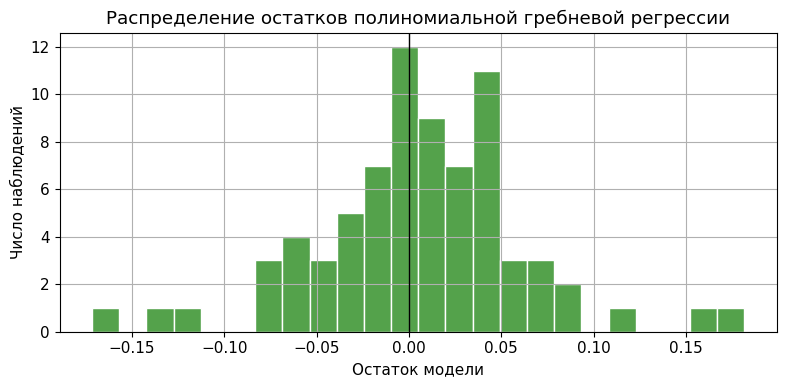

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=24, color="#54a24b", edgecolor="white")
ax.axvline(0.0, color="black", linewidth=1)
ax.set_xlabel("Остаток модели")
ax.set_ylabel("Число наблюдений")
ax.set_title("Распределение остатков полиномиальной гребневой регрессии")
plt.tight_layout()
plt.show()


## Ошибки по диапазонам КПД

Средняя метрика может скрывать то, что модель хорошо работает в одной области
КПД и хуже в другой. Поэтому полезно сгруппировать тестовые наблюдения по
диапазонам фактического КПД и построить диаграмму размаха остатков.


/tmp/ipykernel_6808/1487519527.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=[str(band) for band in bands])


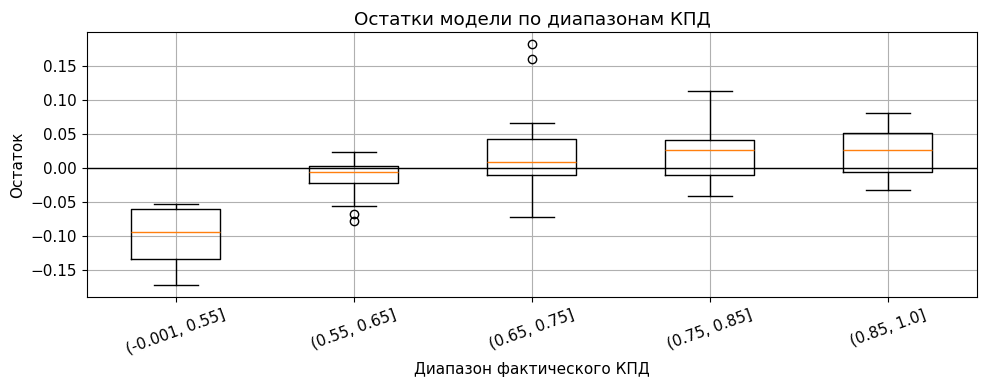

,count,mean,std
efficiency_band,,,
"(-0.001, 0.55]",6,-0.100986,0.049543
"(0.55, 0.65]",13,-0.016535,0.031132
"(0.65, 0.75]",26,0.018936,0.057022
"(0.75, 0.85]",21,0.022351,0.040435
"(0.85, 1.0]",9,0.024069,0.040001


In [18]:
residual_analysis = pd.DataFrame(
    {
        "actual_efficiency": y_test,
        "predicted_efficiency": selected_pred,
        "residual": residuals,
    }
).reset_index(drop=True)
residual_analysis["efficiency_band"] = pd.cut(
    residual_analysis["actual_efficiency"],
    bins=[0.0, 0.55, 0.65, 0.75, 0.85, 1.0],
    include_lowest=True,
)

bands = residual_analysis["efficiency_band"].cat.categories
box_data = [
    residual_analysis.loc[residual_analysis["efficiency_band"] == band, "residual"]
    for band in bands
]

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(box_data, labels=[str(band) for band in bands])
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xlabel("Диапазон фактического КПД")
ax.set_ylabel("Остаток")
ax.set_title("Остатки модели по диапазонам КПД")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

residual_analysis.groupby("efficiency_band", observed=True)["residual"].agg(["count", "mean", "std"])


## Влияние сложности модели

Сложность модели должна соответствовать сложности физической зависимости. Если
модель слишком проста, она не описывает существенную нелинейность. Если модель
слишком сложна, она может начать описывать случайный шум обучающей выборки.
Это явление называется переобучением, overfitting.


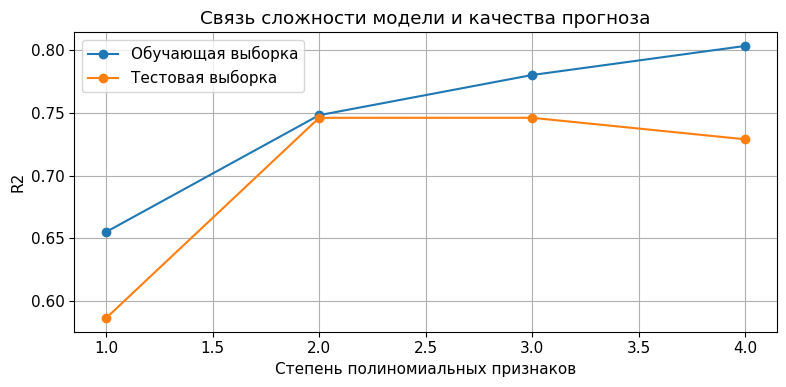

,degree,train_R2,test_R2
0,1,0.654995,0.586287
1,2,0.748109,0.746012
2,3,0.780152,0.746044
3,4,0.803345,0.728906


In [19]:
complexity_rows = []

for degree in [1, 2, 3, 4]:
    model = Pipeline(
        steps=[
            ("polynomial_features", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    )
    model.fit(X_train, y_train)
    complexity_rows.append(
        {
            "degree": degree,
            "train_R2": r2_score(y_train, model.predict(X_train)),
            "test_R2": r2_score(y_test, model.predict(X_test)),
        }
    )

complexity_df = pd.DataFrame(complexity_rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(complexity_df["degree"], complexity_df["train_R2"], marker="o", label="Обучающая выборка")
ax.plot(complexity_df["degree"], complexity_df["test_R2"], marker="o", label="Тестовая выборка")
ax.set_xlabel("Степень полиномиальных признаков")
ax.set_ylabel("R2")
ax.set_title("Связь сложности модели и качества прогноза")
ax.legend()
plt.tight_layout()
plt.show()

complexity_df


## Задание для аудиторного отчета

1. Укажите признаки и целевую переменную.
2. Сравните базовую модель, линейную регрессию и полиномиальную гребневую
   регрессию (Ridge regression) по MAE, RMSE и R2.
3. Опишите, какая модель лучше описывает тестовую выборку.
4. Переведите MAE и RMSE лучшей модели в процентные пункты КПД.
5. Измените степень полинома или параметр `alpha` и укажите, как меняются
   метрики качества на обучающей и тестовой выборках.
6. Объясните, почему нельзя использовать `output_power_w` и `loss_power_w`
   без проверки на утечку данных.
7. Укажите, можно ли использовать модель для предварительной инженерной
   оценки КПД, и назовите не менее двух ограничений такого применения.

Ответ группы:


In [20]:
# Самостоятельный эксперимент.
# Измените значения degree и alpha, затем повторно выполните ячейку.
experiment_degree = 2
experiment_alpha = 1.0

experiment_model = Pipeline(
    steps=[
        ("polynomial_features", PolynomialFeatures(degree=experiment_degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=experiment_alpha)),
    ]
)

experiment_model.fit(X_train, y_train)
experiment_pred = experiment_model.predict(X_test)
pd.Series(regression_metrics(y_test, experiment_pred), name="experiment")


MAE     0.041307
RMSE    0.056623
R2      0.746012
Name: experiment, dtype: float64

## Реестр найденных наборов данных и развернутые задания

В этом блокноте используются все найденные источники данных через единый
реестр. Реестр не загружает крупные внешние архивы автоматически. Он задает
отдельные расширенные задания, которые можно выполнять после базовой части
занятия.

Каждое задание включает:

1. теоретический блок - какие понятия и ограничения нужно объяснить;
2. практический блок - какие действия выполнить в Jupyter Notebook;
3. ожидаемые артефакты - какие таблицы, графики и выводы должны быть в отчете;
4. риски - какие ограничения источника необходимо учесть.

Ниже показаны все найденные наборы данных, а затем задания, относящиеся к
занятию 2.


In [21]:
dataset_catalog = pd.read_csv(CATALOG_FILE)
dataset_assignments = pd.read_csv(ASSIGNMENTS_FILE)

pd.set_option("display.max_colwidth", 120)

all_datasets_view = dataset_catalog[
    [
        "dataset_id",
        "name",
        "object",
        "license",
        "access",
        "size_note",
        "lessons",
        "risk_level",
        "implementation_status",
    ]
]
all_datasets_view


,dataset_id,name,object,license,access,size_note,lessons,risk_level,implementation_status
0,zenodo_motor_temperature,ElectricMotorTemperature,"электродвигатель, представленный многомерными временными рядами (multivariate time series)",CC BY 4.0,прямая загрузка Zenodo,"TRAIN около 104 МБ, TEST около 45 МБ; фрагменты длиной 60 отсчетов","1,2,3",средний,external_notebook_ready
1,pmsm_inverter_fault_zenodo,Comprehensive Dataset for Fault Detection and Diagnosis in Inverter-Driven PMSM Systems,"PMSM-инвертор, лабораторная диагностика",CC BY 4.0,прямая загрузка Zenodo,компактный архив около 1.1 МБ по данным карточки источника,"1,2,3",низкий,external_notebook_ready
2,ev_powertrain_efficiency,Processed Data for EV Powertrain Efficiency,электропривод транспортного средства,CC BY 4.0,Mendeley Data,размер на карточке не указан,"1,2",средний,external_notebook_ready
3,system_identification_electric_motor,Identifying the Physics Behind an Electric Motor,PMSM и двухуровневый IGBT-инвертор,Data files copyright original authors; условия переиздания неясны,Kaggle,около 40 млн образцов,"1,2",высокий,methodology_only
4,ipmsm_motor_parameters,Dataset for motor parameters of IPMSM,параметры и геометрия синхронного двигателя с внутренним расположением постоянных магнитов (Interior Permanent Magne...,CC BY-SA 4.0,Kaggle,CSV и изображения геометрии,"1,2",средний,methodology_only
5,pmsm_foc_mendeley,PMSM_FOC dataset,PMSM с Field Oriented Control,CC BY 4.0,Mendeley Data,размер на карточке не указан,"1,2,3",средний,methodology_only
6,permanent_magnet_dc_worm_motor,Permanent Magnet DC Worm Geared Motor Data,двигатель постоянного тока с червячным редуктором,CC BY 4.0,Mendeley Data,около 27 МБ по статье Data in Brief,"1,2,3",средний,methodology_only
7,uci_ai4i_2020,AI4I 2020 Predictive Maintenance Dataset,синтетическая промышленная установка,CC BY 4.0,прямой UCI-доступ без регистрации,"10 000 строк, 14 столбцов, около 510 КБ","1,3",низкий,methodology_only
8,figshare_three_phase_induction_fault,MOTOR FAULT DETECTION DATA,трехфазный асинхронный двигатель,CC BY 4.0,прямая загрузка Figshare,"около 5.16 ГБ, 10 CSV-файлов","1,3",высокий,methodology_only
9,paderborn_bearing,Paderborn University Bearing Data Center,электромеханический привод с подшипниковыми дефектами,CC BY-NC 4.0,прямые MATLAB-файлы с сайта университета,"32 состояния, 4 режима, 20 измерений на режим","1,3",высокий,methodology_only


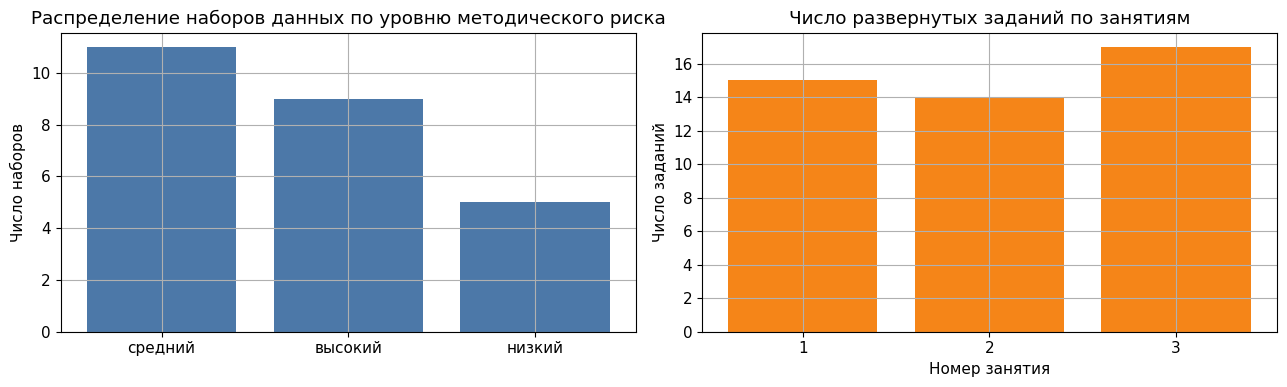

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

risk_counts = dataset_catalog["risk_level"].value_counts()
axes[0].bar(risk_counts.index, risk_counts.values, color="#4c78a8")
axes[0].set_title("Распределение наборов данных по уровню методического риска")
axes[0].set_ylabel("Число наборов")

lesson_counts = (
    dataset_assignments["lesson"]
    .astype(str)
    .value_counts()
    .sort_index()
)
axes[1].bar(lesson_counts.index, lesson_counts.values, color="#f58518")
axes[1].set_title("Число развернутых заданий по занятиям")
axes[1].set_xlabel("Номер занятия")
axes[1].set_ylabel("Число заданий")

plt.tight_layout()
plt.show()


In [23]:
lesson_assignments = dataset_assignments[
    dataset_assignments["lesson"].astype(str) == "2"
].copy()

lesson_assignments[
    [
        "assignment_id",
        "assignment_title",
        "implementation_status",
        "dataset_structure",
        "minimum_working_subset",
        "target_rule",
        "split_rule",
        "theory_block",
        "practice_block",
        "recommended_visualizations",
        "expected_artifacts",
        "control_questions",
        "success_criteria",
        "risk_note",
    ]
]


,assignment_id,assignment_title,implementation_status,dataset_structure,minimum_working_subset,target_rule,split_rule,theory_block,practice_block,recommended_visualizations,expected_artifacts,control_questions,success_criteria,risk_note
1,zenodo_motor_temperature_regression,Регрессионная модель: ElectricMotorTemperature,external_notebook_ready,"Объект: электродвигатель, представленный многомерными временными рядами (multivariate time series). Формат данных: T...",Использовать компактный CSV из `data/processed/external`; при чтении исходного .ts-файла сохранять profile_id и не п...,Цель: целевая температура временного фрагмента; саму целевую температуру исключить из признаков.,Разбивать по profile_id или по временным блокам; случайное перемешивание соседних фрагментов не применять.,Теоретический блок должен объяснить постановку регрессии (regression) как задачи прогнозирования непрерывной величин...,"Практический блок включает выбор целевой переменной, исключение признаков с утечкой, подготовку обучающей и тестовой...",1. Распределение целевой переменной. 2. Диаграммы рассеяния целевой переменной с основными признаками. 3. График фак...,"Таблица метрик качества, график сравнения моделей, график фактических и прогнозных значений, график остатков, вывод ...",Почему выбранная цель является непрерывной величиной? Какие признаки доступны до момента прогноза? Что показывает ос...,"Зачет: корректная цель, исключение утечек, базовая модель, MAE/RMSE/R2, график остатков.",физические имена каналов в архиве не заданы; требуется групповое разбиение по profile_id
4,pmsm_inverter_fault_zenodo_regression,Регрессионная модель: Comprehensive Dataset for Fault Detection and Diagnosis in Inverter-Driven PMSM Systems,external_notebook_ready,"Объект: PMSM-инвертор, лабораторная диагностика. Формат данных: CSV / zip. Размер или масштаб: компактный архив окол...","Для базовой работы использовать полный файл, если он загружается менее чем за 2-3 минуты.",Цель: выбрать одну непрерывную физическую величину и обосновать ее доступность.,Использовать фиксированное train/test-разбиение 75/25 с random_state; для дисбаланса классов применять stratify.,Теоретический блок должен объяснить постановку регрессии (regression) как задачи прогнозирования непрерывной величин...,"Практический блок включает выбор целевой переменной, исключение признаков с утечкой, подготовку обучающей и тестовой...",1. Распределение целевой переменной. 2. Диаграммы рассеяния целевой переменной с основными признаками. 3. График фак...,"Таблица метрик качества, график сравнения моделей, график фактических и прогнозных значений, график остатков, вывод ...",Почему выбранная цель является непрерывной величиной? Какие признаки доступны до момента прогноза? Что показывает ос...,"Зачет: корректная цель, исключение утечек, базовая модель, MAE/RMSE/R2, график остатков.","исходная постановка ближе к диагностике, чем к расчету КПД"
7,ev_powertrain_efficiency_regression,Регрессионная модель: Processed Data for EV Powertrain Efficiency,external_notebook_ready,Объект: электропривод транспортного средства. Формат данных: CSV и Jupyter Notebook. Размер или масштаб: размер на к...,"Для базовой работы использовать полный файл, если он загружается менее чем за 2-3 минуты.","Цель: расчетный КПД силовой установки; признаки, прямо входящие в формулу КПД, использовать только после проверки ут...",Использовать фиксированное train/test-разбиение 75/25 с random_state; для дисбаланса классов применять stratify.,Теоретический блок должен объяснить постановку регрессии (regression) как задачи прогнозирования непрерывной величин...,"Практический блок включает выбор целевой переменной, исключение признаков с утечкой, подготовку обучающей и тестовой...",1. Распределение целевой переменной. 2. Диаграммы рассеяния целевой переменной с основными признаками. 3. График фак...,"Таблица метрик качества, график сравнения моделей, график фактических и прогнозных значений, график остатков, вывод ...",Почему выбранная цель являет

## Индивидуальное расширенное задание

Выберите один набор данных из таблицы выше и выполните соответствующее
развернутое задание. Если источник требует учетной записи, крупной загрузки
или специального формата файлов, допускается использовать малое заранее
подготовленное подмножество. В отчете обязательно укажите, была ли работа
выполнена на полном наборе данных, подмножестве или только на методическом
описании источника.


## Методический комментарий для преподавателя

При фиксированном разбиении данных ожидаемый порядок результатов:

1. базовая модель среднего значения имеет MAE около 0.093 и R2 около 0;
2. линейная регрессия на строгих признаках дает R2 около 0.58;
3. полиномиальная гребневая регрессия второй степени дает R2 около 0.75;
4. демонстрация утечки с `current_a`, `output_power_w` и `loss_power_w`
   может дать R2 около 0.94, но этот результат не является допустимым
   ориентиром качества базовой модели;
5. вывод должен подчеркивать, что более высокая метрика не отменяет
   необходимости физической проверки модели;
6. студент должен заметить риск прямой и косвенной утечки данных.


In [24]:
print(metrics_df.round(4))


                      MAE    RMSE      R2
model                                    
mean_baseline      0.0929  0.1130 -0.0113
linear_regression  0.0528  0.0726  0.5829
polynomial_ridge   0.0413  0.0566  0.7460
